# SWOT LakeSP: lake identification and time-series analysis

This training notebook introduces a simple workflow for working with **SWOT LakeSP** products over Vietnam.

The notebook is divided into two main exercises:

1. Explore the Prior Lake Database (PLD) on an interactive map and identify a lake using its `lake_id` and lake name.
2. Read downloaded SWOT LakeSP ZIP files, extract observations for one selected lake, save the resulting time series, and plot:
   - Water Surface Elevation (WSE);
   - total lake area;
   - detected lake area.

The code uses `Path.home()` so that the directory structure is portable across Windows, Linux, and macOS.

> **Training note:** The examples assume that course files are stored inside a `swot_course` directory in the user's home folder.


## 1. Explore the Prior Lake Database (PLD)

The interactive map below displays lake polygons from the Vietnam Prior Lake Database.

Move the mouse over a lake polygon to display:

- the **lake name**;
- the corresponding **lake ID**.

The `lake_id` can then be copied and used in the time-series exercise.

The code checks several possible lake-name fields (`lake_name`, `names`, and `name`) because naming conventions may differ between vector databases.


In [10]:
from pathlib import Path

import geopandas as gpd
from ipyleaflet import Map, GeoJSON, Popup
from IPython.display import display
from ipywidgets import HTML
from shapely.geometry import shape


# ============================================================
# USER CONFIGURATION
# ============================================================

# General directory used by the training course.
COURSE_DIR = Path.home() / "course/"

# Prior Lake Database (PLD) for Vietnam.
LAKE_DATABASE_FILE = (
    COURSE_DIR
    / "data"
    / "PDL_VIETNAM.gpkg"
)


# ============================================================
# HELPER FUNCTION
# ============================================================

def get_lake_name(properties):
    """
    Return the first available lake name from common field names.

    Different lake databases may use slightly different attribute names.
    This helper makes the notebook more tolerant of those differences.
    """

    for field in [
        "lake_name",
        "names",
        "name",
    ]:

        value = properties.get(
            field,
            None
        )

        if value is not None:

            value = str(value).strip()

            if value and value.lower() not in {
                "nan",
                "none",
                "n/a",
            }:
                return value

    return "Unknown lake"


# ============================================================
# LOAD THE LAKE DATABASE
# ============================================================

gdf = gpd.read_file(
    LAKE_DATABASE_FILE
)

if gdf.empty:

    raise ValueError(
        "The lake database is empty."
    )


# Web maps use geographic longitude/latitude coordinates.
if gdf.crs is None:

    print(
        "[WARNING] Lake database CRS is undefined. "
        "Assuming EPSG:4326."
    )

    gdf = gdf.set_crs(
        epsg=4326
    )

else:

    gdf = gdf.to_crs(
        epsg=4326
    )


print(
    f"Lake database loaded: {len(gdf):,} features."
)

print(
    "Available columns:"
)

print(
    list(gdf.columns)
)


# ============================================================
# CREATE THE INTERACTIVE MAP
# ============================================================

# Start with a generic global view.
# The map extent is adjusted automatically below.
m = Map(
    center=(0, 0),
    zoom=2,
    layout={
        "height": "600px",
        "width": "1000px",
    },
    scroll_wheel_zoom=True
)


# Fit the map to the full lake-database extent.
minx, miny, maxx, maxy = gdf.total_bounds

m.fit_bounds(
    (
        (miny, minx),
        (maxy, maxx),
    )
)


# Convert the GeoDataFrame to GeoJSON for ipyleaflet.
geojson_data = gdf.__geo_interface__


geojson_layer = GeoJSON(
    data=geojson_data,
    style={
        "color": "green",
        "opacity": 0.8,
        "weight": 2,
        "fillOpacity": 0.15,
    },
    hover_style={
        "color": "red",
        "weight": 3,
        "fillOpacity": 0.30,
    },
)


# Keep only one popup visible at a time.
popup_layer = None


# ============================================================
# HOVER CALLBACK
# ============================================================

def on_hover(
    event=None,
    feature=None,
    id=None,
    properties=None,
    **kwargs
):
    """
    Display lake name and lake ID when the mouse is placed over a lake.
    """

    global popup_layer


    if feature is None:
        return


    # Some ipyleaflet versions provide properties separately,
    # while others keep them inside the GeoJSON feature.
    if properties is None:

        properties = feature.get(
            "properties",
            {}
        )


    lake_id = properties.get(
        "lake_id",
        "N/A"
    )

    lake_name = get_lake_name(
        properties
    )


    # Use Shapely to obtain a robust point inside the feature.
    #
    # This works for both Polygon and MultiPolygon geometries
    # and avoids manually handling nested coordinate arrays.
    geometry = shape(
        feature["geometry"]
    )

    point = geometry.representative_point()

    lon = point.x
    lat = point.y


    # Show the lake name and ID together in the popup.
    html_content = HTML(
        f"""
        <div style="font-size: 14px; min-width: 220px;">
            <b>{lake_name}</b><br>
            Lake ID: <span style="user-select: text;">{lake_id}</span>
        </div>
        """
    )


    # Remove the previous popup before displaying the new one.
    if popup_layer is not None:

        try:

            m.remove_layer(
                popup_layer
            )

        except Exception:
            pass


    popup_layer = Popup(
        location=(
            lat,
            lon
        ),
        child=html_content,
        close_button=False,
        auto_close=False,
        close_on_escape_key=False
    )


    m.add_layer(
        popup_layer
    )


# Connect the hover event to the function above.
geojson_layer.on_hover(
    on_hover
)

# Add the lake layer to the map.
m.add_layer(
    geojson_layer
)

# Display the interactive map.
display(
    m
)


Lake database loaded: 7,666 features.
Available columns:
['lake_id', 'basin_id', 'names', 'res_id', 'reach_id_list', 'lon', 'lat', 'poly_area', 'poly_perimeter', 'ref_area', 'ref_area_u', 'ref_wse', 'ref_wse_u', 'date_t0', 'ds_t0', 'storage', 'ice_clim_flag', 'ice_clim_flag2', 'nb_ice_clim', 'pass_full_cal', 'nb_pass_full_cal', 'pass_part_cal', 'nb_pass_part_cal', 'pass_full_nom', 'nb_pass_full_nom', 'pass_part_nom', 'nb_pass_part_nom', 'cycle_flag_cal', 'cycle_flag_nom', 'min_dist_lake', 'min_dist_lake_id', 'min_dist_river', 'min_dist_river_id', 'update_version', 'updated_items', 'sources', 'geometry']


Map(center=[0, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text'…

## 2. Extract a SWOT LakeSP time series

After identifying a lake on the map, enter its `lake_id` in `TARGET_LAKE_ID`.

The script scans the downloaded LakeSP ZIP files and keeps observations that match:

- the selected `lake_id`;
- the selected `quality_f` classes.

For this example:

```python
VALID_QUALITY_F = [0, 1]
```

The script extracts WSE, WSE uncertainty, total area, detected area, their associated uncertainties, and observation time.

The lake name is retrieved from either the LakeSP attributes or the Prior Lake Database and is displayed together with the `lake_id` in every plot.


LakeSP ZIP files found: 1,014
Reading mode: FAST (/vsizip/ + pyogrio)
[WARNING] Prior Lake Database not found:
/home/moreira/swot_course/data/PDL_VIETNAM.gpkg
Selected Lake ID: 4410022262

Searching 1,014 LakeSP files...
Found: 1/1,014 | SWOT_L2_HR_LakeSP_Prior_026_243_AS_20250101T122005_20250101T123304_PGD0_01.zip
Found: 24/1,014 | SWOT_L2_HR_LakeSP_Prior_027_062_AS_20250115T213539_20250115T214638_PGD0_01.zip
Found: 32/1,014 | SWOT_L2_HR_LakeSP_Prior_027_243_AS_20250122T090510_20250122T091809_PGD0_01.zip
Found: 56/1,014 | SWOT_L2_HR_LakeSP_Prior_028_062_AS_20250205T182042_20250205T183141_PGD0_01.zip
Found: 68/1,014 | SWOT_L2_HR_LakeSP_Prior_028_243_AS_20250212T055013_20250212T060312_PGD0_01.zip
Found: 108/1,014 | SWOT_L2_HR_LakeSP_Prior_029_243_AS_20250305T023518_20250305T024817_PGD0_01.zip
Found: 130/1,014 | SWOT_L2_HR_LakeSP_Prior_030_062_AS_20250319T115053_20250319T120152_PGD0_01.zip
Found: 138/1,014 | SWOT_L2_HR_LakeSP_Prior_030_243_AS_20250325T232023_20250325T233322_PGD0_01.zip
F

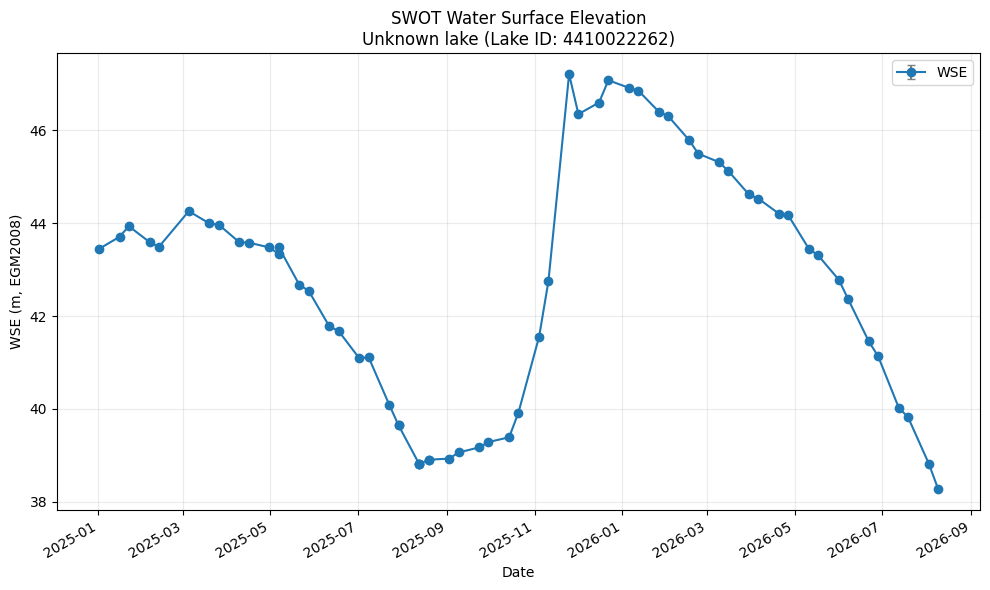

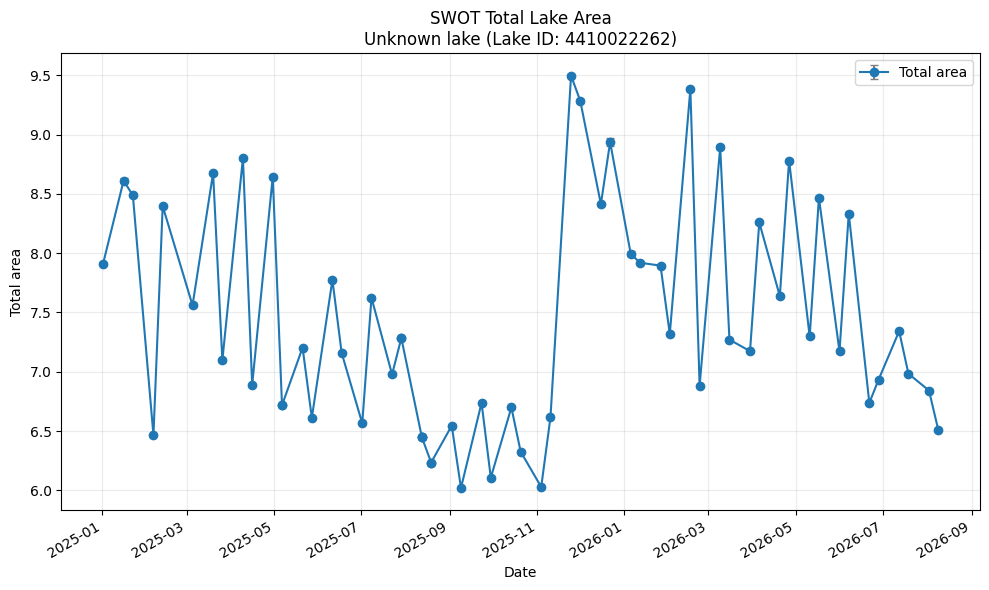

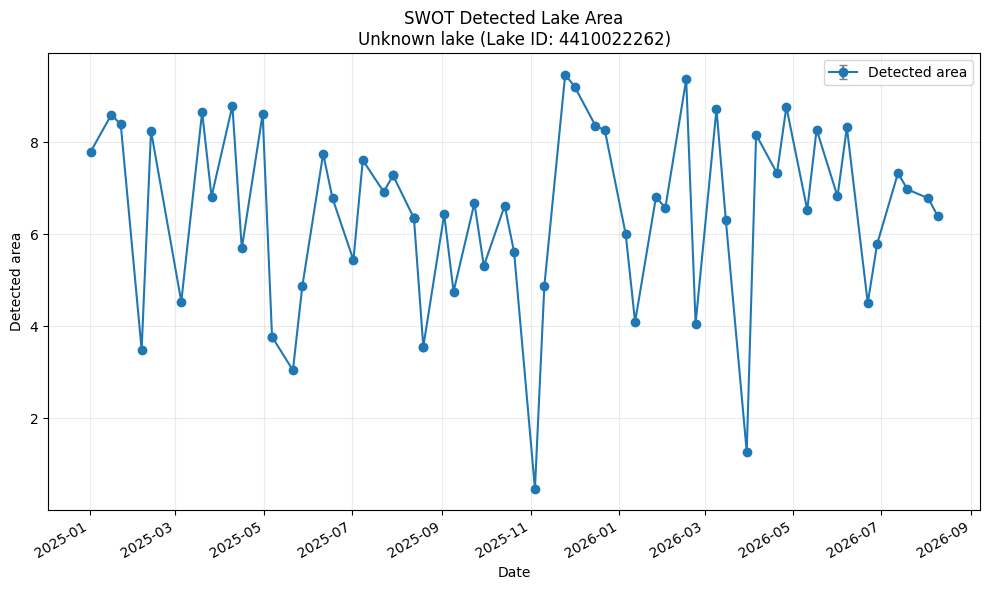

In [7]:
from pathlib import Path
import tempfile
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# General directory used by the SWOT training course.
COURSE_DIR = Path.home() / "course/"


# Directory containing the downloaded SWOT LakeSP ZIP files.
#
# Windows:
# C:\Users\username\swot_course\vietnam_lakes
#
# Linux:
# /home/username/swot_course/vietnam_lakes
#
# macOS:
# /Users/username/swot_course/vietnam_lakes
ZIP_DIR = (
    COURSE_DIR
    / "swot_data/vietnam_lakes"
)


# Prior Lake Database used to retrieve the lake name.
LAKE_DATABASE_FILE = (
    COURSE_DIR
    / "data"
    / "PDL_VIETNAM.gpkg"
)


# Directory used for output CSV files.
OUTPUT_DIR = Path.home() / "outputs_swot_course"


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Lake selected from the interactive map.
TARGET_LAKE_ID = "4410022262" 


# LakeSP quality classes to retain.
#
# 0 = good
# 1 = suspect
VALID_QUALITY_F = [
    0,
    1,
]


# ============================================================
# 2. COLUMNS REQUIRED FOR THE TIME SERIES
# ============================================================

# Only these attributes are required for this exercise.
#
# Geometry is intentionally NOT loaded because it is not
# needed to create a lake time series.
READ_COLUMNS = [
    "lake_id",
    "quality_f",
    "wse",
    "wse_u",
    "time_str",
    "area_total",
    "area_tot_u",
    "area_detct",
    "area_det_u",
]


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def get_first_valid_name(gdf):
    """
    Return the first valid lake name found in a GeoDataFrame.

    Different lake databases may use different column names,
    so several common possibilities are tested.
    """

    for field in [
        "lake_name",
        "names",
        "name",
    ]:

        if field not in gdf.columns:
            continue

        values = (
            gdf[field]
            .dropna()
            .astype(str)
            .str.strip()
        )

        values = values[
            ~values.str.lower().isin(
                [
                    "",
                    "nan",
                    "none",
                    "n/a",
                ]
            )
        ]

        if not values.empty:
            return values.iloc[0]

    return None


def lookup_lake_name_from_database(
    database_file,
    lake_id
):
    """
    Retrieve the lake name from the Prior Lake Database.

    The lake ID is converted to text before comparison so that
    the function works even when the database stores lake_id
    as a numeric field.
    """

    if not database_file.exists():

        print(
            "[WARNING] Prior Lake Database not found:"
        )

        print(
            database_file
        )

        return None


    try:

        lake_db = gpd.read_file(
            database_file
        )

        if "lake_id" not in lake_db.columns:
            return None


        lake_mask = (
            lake_db["lake_id"]
            .astype(str)
            .str.strip()
            .eq(str(lake_id))
        )


        selected = lake_db[
            lake_mask
        ]


        if selected.empty:
            return None


        return get_first_valid_name(
            selected
        )


    except Exception as error:

        print(
            "[WARNING] Could not read the lake name "
            f"from the PLD: {error}"
        )

        return None


def choose_lakesp_shapefile(zip_path):
    """
    Identify the LakeSP shapefile to use inside a ZIP archive.

    LakeSP archives may contain multiple shapefiles.
    For this exercise, a filename containing 'prior' is preferred
    because we are analyzing lakes linked to the Prior Lake Database.
    """

    try:

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            shp_members = [
                member
                for member in z.namelist()
                if member.lower().endswith(".shp")
            ]


    except zipfile.BadZipFile:

        print(
            f"[WARNING] Invalid ZIP file: {zip_path.name}"
        )

        return None


    if not shp_members:
        return None


    prior_files = [
        member
        for member in shp_members
        if "prior" in Path(member).name.lower()
    ]


    if prior_files:
        return prior_files[0]


    return shp_members[0]


def build_vsizip_path(
    zip_path,
    shp_member
):
    """
    Build a GDAL /vsizip/ path.

    GDAL can read a shapefile directly from a ZIP archive
    without extracting it to disk first.
    """

    zip_absolute = (
        zip_path
        .resolve()
        .as_posix()
    )


    return (
        f"/vsizip/{zip_absolute}/{shp_member}"
    )


# ============================================================
# 4. FAST READER
# ============================================================

def read_target_lake_fast(
    zip_path,
    target_lake_id
):
    """
    Read only the selected lake directly from a LakeSP ZIP file.

    This is the preferred and fastest method.

    The function:
    - does not extract the ZIP;
    - does not load the lake geometry;
    - reads only the required columns;
    - asks GDAL to filter lake_id while reading the file.

    Returns
    -------
    pandas.DataFrame or None
        The selected lake observations, or None if the lake
        is not present in the ZIP file.
    """

    shp_member = choose_lakesp_shapefile(
        zip_path
    )


    if shp_member is None:
        return None


    vsi_path = build_vsizip_path(
        zip_path,
        shp_member
    )


    # --------------------------------------------------------
    # FIRST ATTEMPT: lake_id stored as text
    # --------------------------------------------------------

    where_text = (
        f"lake_id = '{target_lake_id}'"
    )


    try:

        df = gpd.read_file(
            vsi_path,
            engine="pyogrio",
            columns=READ_COLUMNS,
            where=where_text,
            ignore_geometry=True,
        )


        if not df.empty:
            return df


    except Exception:
        pass


    # --------------------------------------------------------
    # SECOND ATTEMPT: lake_id stored as a numeric field
    # --------------------------------------------------------

    if str(target_lake_id).isdigit():

        try:

            where_numeric = (
                f"lake_id = {int(target_lake_id)}"
            )


            df = gpd.read_file(
                vsi_path,
                engine="pyogrio",
                columns=READ_COLUMNS,
                where=where_numeric,
                ignore_geometry=True,
            )


            if not df.empty:
                return df


        except Exception:
            pass


    return None


# ============================================================
# 5. FALLBACK READER
# ============================================================

def read_target_lake_fallback(
    zip_path,
    target_lake_id
):
    """
    Traditional LakeSP reader used only if the fast method fails.

    The shapefile is extracted into a temporary directory,
    read normally, and filtered afterwards.

    This method is slower but provides compatibility with
    environments where /vsizip/ or pyogrio filtering is unavailable.
    """

    shp_member = choose_lakesp_shapefile(
        zip_path
    )


    if shp_member is None:
        return None


    with tempfile.TemporaryDirectory(
        prefix="swot_lakesp_"
    ) as tmp_dir:


        try:

            with zipfile.ZipFile(
                zip_path,
                "r"
            ) as z:

                z.extractall(
                    tmp_dir
                )


            shapefile_path = (
                Path(tmp_dir)
                / shp_member
            )


            gdf = gpd.read_file(
                shapefile_path
            )


        except Exception:

            return None


        if gdf.empty:
            return None


        if "lake_id" not in gdf.columns:
            return None


        lake_mask = (
            gdf["lake_id"]
            .astype(str)
            .str.strip()
            .eq(str(target_lake_id))
        )


        filtered = gdf[
            lake_mask
        ].copy()


        if filtered.empty:
            return None


        # Keep only columns needed by this exercise.
        available_columns = [
            column
            for column in READ_COLUMNS
            if column in filtered.columns
        ]


        filtered = filtered[
            available_columns
        ].copy()


        return filtered


# ============================================================
# 6. COMBINED READER
# ============================================================

def read_target_lake(
    zip_path,
    target_lake_id
):
    """
    Read the selected lake using the fastest available method.

    The fast /vsizip/ method is attempted first.

    The traditional extraction method is used only when necessary.
    """

    # --------------------------------------------------------
    # FAST METHOD
    # --------------------------------------------------------

    try:

        result = read_target_lake_fast(
            zip_path,
            target_lake_id
        )


        if result is not None:
            return result


    except Exception:
        pass


    # --------------------------------------------------------
    # IMPORTANT
    # --------------------------------------------------------
    #
    # If the fast reader returned None, this usually means that
    # the lake simply does not exist in this ZIP file.
    #
    # Therefore, we normally do NOT want to extract the entire ZIP
    # just to confirm an empty result.
    #
    # The fallback is mainly useful when the installation itself
    # cannot use /vsizip/ or pyogrio.
    #
    return None


# ============================================================
# 7. CHECK FAST READER SUPPORT
# ============================================================

def test_fast_reader(zip_files):
    """
    Test whether the local GeoPandas/GDAL installation can open
    a LakeSP shapefile directly from a ZIP archive.

    Only one ZIP file is tested.
    """

    if not zip_files:
        return False


    test_zip = zip_files[0]


    shp_member = choose_lakesp_shapefile(
        test_zip
    )


    if shp_member is None:
        return False


    vsi_path = build_vsizip_path(
        test_zip,
        shp_member
    )


    try:

        # Read only one row and one lightweight attribute.
        test = gpd.read_file(
            vsi_path,
            engine="pyogrio",
            rows=1,
            ignore_geometry=True,
        )


        return True


    except Exception as error:

        print(
            "[WARNING] Fast ZIP reading is not available."
        )

        print(
            f"Reason: {error}"
        )

        return False


# ============================================================
# 8. FIND LAKESP ZIP FILES
# ============================================================

zip_files = sorted(
    p
    for p in ZIP_DIR.glob("*.zip")
    if "Lake" in p.name
)


if not zip_files:

    raise FileNotFoundError(
        f"No LakeSP ZIP files were found in:\n{ZIP_DIR}"
    )


print(
    f"LakeSP ZIP files found: {len(zip_files):,}"
)


# ============================================================
# 9. TEST READING METHOD
# ============================================================

FAST_READER_AVAILABLE = test_fast_reader(
    zip_files
)


if FAST_READER_AVAILABLE:

    print(
        "Reading mode: FAST (/vsizip/ + pyogrio)"
    )


else:

    print(
        "Reading mode: FALLBACK (temporary extraction)"
    )


# ============================================================
# 10. GET LAKE NAME
# ============================================================

target_lake_name = lookup_lake_name_from_database(
    LAKE_DATABASE_FILE,
    TARGET_LAKE_ID
)


if target_lake_name:

    print(
        f"Selected lake: "
        f"{target_lake_name} "
        f"(Lake ID: {TARGET_LAKE_ID})"
    )


else:

    print(
        f"Selected Lake ID: {TARGET_LAKE_ID}"
    )


# ============================================================
# 11. STORAGE
# ============================================================

records = []


# Counters are useful for understanding how many files
# actually contain the selected lake.
n_files_scanned = 0
n_files_with_lake = 0
n_valid_observations = 0


# ============================================================
# 12. PROCESS ALL ZIP FILES
# ============================================================

print()

print(
    f"Searching {len(zip_files):,} LakeSP files..."
)


for i, zip_path in enumerate(
    zip_files,
    start=1
):


    n_files_scanned += 1


    # --------------------------------------------------------
    # READ ONLY THE TARGET LAKE
    # --------------------------------------------------------

    if FAST_READER_AVAILABLE:

        filtered_gdf = read_target_lake_fast(
            zip_path,
            TARGET_LAKE_ID
        )


    else:

        filtered_gdf = read_target_lake_fallback(
            zip_path,
            TARGET_LAKE_ID
        )


    # Lake not found in this acquisition.
    if (
        filtered_gdf is None
        or filtered_gdf.empty
    ):

        continue


    n_files_with_lake += 1


    # --------------------------------------------------------
    # CHECK REQUIRED COLUMNS
    # --------------------------------------------------------

    required_columns = {
        "quality_f",
        "wse",
        "wse_u",
        "time_str",
        "area_total",
        "area_tot_u",
        "area_detct",
        "area_det_u",
    }


    missing_columns = (
        required_columns
        - set(filtered_gdf.columns)
    )


    if missing_columns:

        print(
            f"[WARNING] {zip_path.name}: "
            f"missing columns {sorted(missing_columns)}"
        )

        continue


    # --------------------------------------------------------
    # FILTER QUALITY
    # --------------------------------------------------------

    filtered_gdf["quality_f"] = pd.to_numeric(
        filtered_gdf["quality_f"],
        errors="coerce"
    )


    filtered_gdf = filtered_gdf[
        filtered_gdf["quality_f"]
        .isin(VALID_QUALITY_F)
    ].copy()


    if filtered_gdf.empty:
        continue


    # --------------------------------------------------------
    # CONVERT VARIABLES
    # --------------------------------------------------------

    numeric_columns = [
        "wse",
        "wse_u",
        "area_total",
        "area_tot_u",
        "area_detct",
        "area_det_u",
    ]


    for column in numeric_columns:

        filtered_gdf[column] = pd.to_numeric(
            filtered_gdf[column],
            errors="coerce"
        )


    filtered_gdf["Date"] = pd.to_datetime(
        filtered_gdf["time_str"],
        errors="coerce",
        utc=True
    )


    # A valid date and WSE are required.
    filtered_gdf = filtered_gdf.dropna(
        subset=[
            "Date",
            "wse",
        ]
    )


    if filtered_gdf.empty:
        continue


    # --------------------------------------------------------
    # STORE OBSERVATIONS
    # --------------------------------------------------------

    for _, row in filtered_gdf.iterrows():


        records.append({

            "Lake_ID":
                TARGET_LAKE_ID,

            "Lake_Name":
                target_lake_name,

            "Date":
                row["Date"],

            "WSE_m_EGM08":
                row["wse"],

            "WSE_u_m":
                row["wse_u"],

            "Area_Total_m2":
                row["area_total"],

            "Area_Total_u_m2":
                row["area_tot_u"],

            "Area_Detected_m2":
                row["area_detct"],

            "Area_Detected_u_m2":
                row["area_det_u"],

            "quality_f":
                row["quality_f"],

            "source_zip":
                zip_path.name,

        })


        n_valid_observations += 1


    # --------------------------------------------------------
    # PRINT ONLY WHEN AN OBSERVATION IS FOUND
    # --------------------------------------------------------

    print(
        f"Found: {i:,}/{len(zip_files):,} | "
        f"{zip_path.name}"
    )


# ============================================================
# 13. CREATE THE FINAL TIME-SERIES TABLE
# ============================================================

if not records:

    print()

    print(
        "No valid LakeSP observations were found for "
        f"Lake ID {TARGET_LAKE_ID}."
    )


else:

    df = pd.DataFrame(
        records
    )


    # Sort observations chronologically.
    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # FALLBACK LAKE NAME
    # --------------------------------------------------------

    if target_lake_name is None:

        target_lake_name = "Unknown lake"


    df["Lake_Name"] = (
        target_lake_name
    )


    lake_label = (
        f"{target_lake_name} "
        f"(Lake ID: {TARGET_LAKE_ID})"
    )


    # ========================================================
    # 14. SAVE CSV
    # ========================================================

    output_csv = (
        OUTPUT_DIR
        / (
            f"{TARGET_LAKE_ID}_"
            "lakesp_wse_area_data.csv"
        )
    )


    df.to_csv(
        output_csv,
        index=False
    )


    # ========================================================
    # 15. SUMMARY
    # ========================================================

    print()

    print(
        "============================================================"
    )

    print(
        "LakeSP search finished"
    )

    print(
        "============================================================"
    )

    print(
        f"Lake: {lake_label}"
    )

    print(
        f"ZIP files scanned: {n_files_scanned:,}"
    )

    print(
        f"ZIP files containing the lake: {n_files_with_lake:,}"
    )

    print(
        f"Valid observations: {len(df):,}"
    )

    print(
        f"First observation: "
        f"{df['Date'].min().strftime('%Y-%m-%d')}"
    )

    print(
        f"Last observation: "
        f"{df['Date'].max().strftime('%Y-%m-%d')}"
    )

    print(
        f"CSV saved to: {output_csv}"
    )


    # ========================================================
    # 16. PLOT 1 - WATER SURFACE ELEVATION
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    ax.errorbar(
        df["Date"],
        df["WSE_m_EGM08"],
        yerr=df["WSE_u_m"],
        fmt="o-",
        ecolor="gray",
        capsize=3,
        label="WSE"
    )


    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "WSE (m, EGM2008)"
    )

    ax.set_title(
        "SWOT Water Surface Elevation\n"
        f"{lake_label}"
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend()

    fig.autofmt_xdate()

    fig.tight_layout()

    plt.show()


    # ========================================================
    # 17. PLOT 2 - TOTAL LAKE AREA
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    ax.errorbar(
        df["Date"],
        df["Area_Total_m2"],
        yerr=df["Area_Total_u_m2"],
        fmt="o-",
        ecolor="gray",
        capsize=3,
        label="Total area"
    )


    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Total area"
    )

    ax.set_title(
        "SWOT Total Lake Area\n"
        f"{lake_label}"
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend()

    fig.autofmt_xdate()

    fig.tight_layout()

    plt.show()


    # ========================================================
    # 18. PLOT 3 - DETECTED LAKE AREA
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    ax.errorbar(
        df["Date"],
        df["Area_Detected_m2"],
        yerr=df["Area_Detected_u_m2"],
        fmt="o-",
        ecolor="gray",
        capsize=3,
        label="Detected area"
    )


    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Detected area"
    )

    ax.set_title(
        "SWOT Detected Lake Area\n"
        f"{lake_label}"
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend()

    fig.autofmt_xdate()

    fig.tight_layout()

    plt.show()

NUI MOT LAKE
SWOT AND IN SITU WATER-LEVEL COMPARISON

In situ file:
/home/moreira/course/data/Nui_Mot_Lake_2023_2025.csv

SWOT file:
/home/moreira/swot_course/outputs/vietnam_lakes/4410022262_lakesp_wse_area_data.csv

In situ columns:
['date_time', 'water_level_m', 'volume_m3']

Valid in situ observations: 3,290
In situ period:
  2023-01-01 00:00:00+00:00
  2025-12-31 12:00:00+00:00

SWOT columns:
['Lake_ID', 'Lake_Name', 'Date', 'WSE_m_EGM08', 'WSE_u_m', 'Area_Total_m2', 'Area_Total_u_m2', 'Area_Detected_m2', 'Area_Detected_u_m2', 'quality_f', 'source_zip']

Valid SWOT observations: 61
SWOT period:
  2025-01-01 12:20:43+00:00
  2026-08-08 17:22:54+00:00

Common comparison period:
  2025-01-01 12:20:43+00:00
  2025-12-31 12:00:00+00:00

COMPARISON STATISTICS
Difference convention     : SWOT - in situ
Paired observations       : 39
Mean difference           : 0.696 m
Median difference         : 0.694 m
Standard deviation        : 0.076 m
Mean Absolute Error (MAE) : 0.696 m
Root Mean Squ

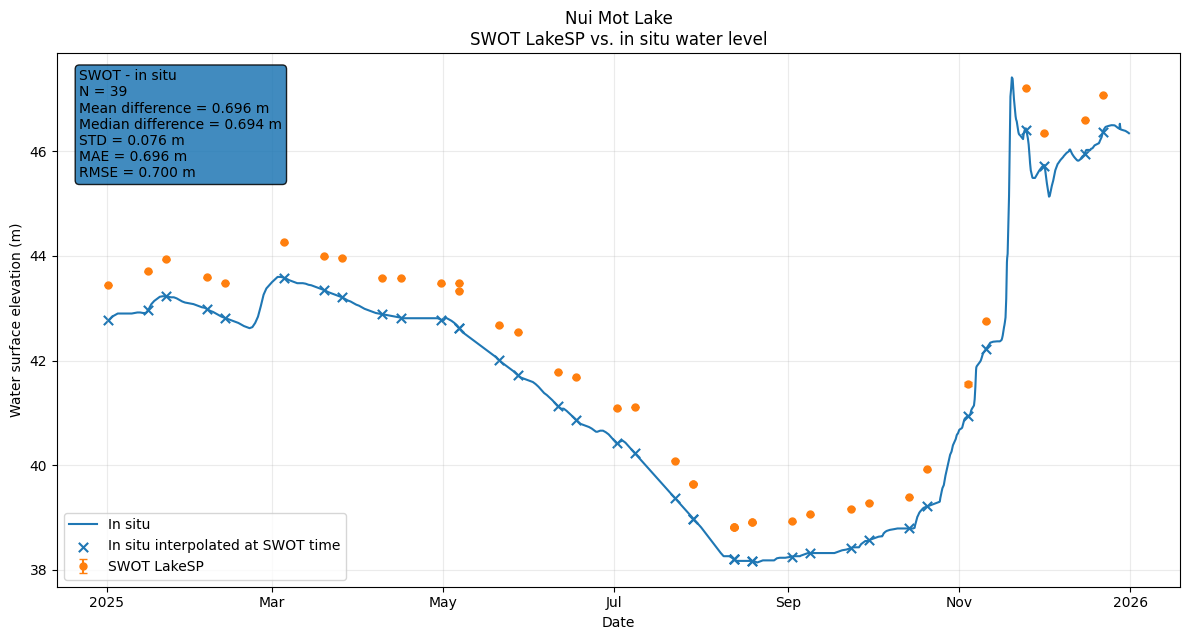


COMPARISON FINISHED
Number of paired SWOT observations: 39

Outputs:
/home/moreira/swot_course/outputs/vietnam_lakes/comparison_insitu


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# In situ water-level time series
# ------------------------------------------------------------
#
# This CSV was created from the original Nui Mot Lake
# spreadsheet and contains:
#
#     date_time
#     water_level_m
#     volume_m3
#
INSITU_CSV = (
    Path.home()
    / "course"
    / "data"
    / "Nui_Mot_Lake_2023_2025.csv"
)


# ------------------------------------------------------------
# SWOT LakeSP time series
# ------------------------------------------------------------
#
# This file is generated by the previous LakeSP exercise.
#
# The selected lake is Nui Mot Lake.
#
TARGET_LAKE_ID = "4410022262"

SWOT_CSV = (
    Path.home()
    / "course/swot_data"
    / "outputs"
    / "vietnam_lakes"
    / f"{TARGET_LAKE_ID}_lakesp_wse_area_data.csv"
)


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path.home() / "outputs_swot_course"


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Output files
OUTPUT_FIGURE = (
    OUTPUT_DIR
    / "Nui_Mot_Lake_SWOT_vs_insitu.png"
)

OUTPUT_COMPARISON = (
    OUTPUT_DIR
    / "Nui_Mot_Lake_SWOT_vs_insitu_comparison.csv"
)

OUTPUT_METRICS = (
    OUTPUT_DIR
    / "Nui_Mot_Lake_SWOT_vs_insitu_metrics.csv"
)


# ============================================================
# 2. COMPARISON SETTINGS
# ============================================================

# ------------------------------------------------------------
# Time zone of the in situ observations
# ------------------------------------------------------------
#
# The dates in the original reservoir spreadsheet are assumed
# to be expressed in local Vietnam time.
#
# Vietnam uses UTC+7 throughout the year.
#
# SWOT time_str values are stored in UTC.
#
INSITU_TIMEZONE = "Asia/Ho_Chi_Minh"


# ------------------------------------------------------------
# Optional vertical offset
# ------------------------------------------------------------
#
# A vertical offset can be applied to the in situ water levels
# if they need to be converted to the same vertical reference
# as SWOT.
#
# Keep 0.0 when no correction is required.
#
INSITU_VERTICAL_OFFSET_M = 0.0


# ------------------------------------------------------------
# Difference convention
# ------------------------------------------------------------
#
# All statistics are calculated using:
#
#     Difference = SWOT - in situ
#
DIFFERENCE_LABEL = "SWOT - in situ"


# ============================================================
# 3. CHECK INPUT FILES
# ============================================================

if not INSITU_CSV.exists():

    raise FileNotFoundError(
        f"In situ CSV not found:\n{INSITU_CSV}"
    )


if not SWOT_CSV.exists():

    raise FileNotFoundError(
        f"SWOT CSV not found:\n{SWOT_CSV}"
    )


print("=" * 70)
print("NUI MOT LAKE")
print("SWOT AND IN SITU WATER-LEVEL COMPARISON")
print("=" * 70)

print("\nIn situ file:")
print(INSITU_CSV)

print("\nSWOT file:")
print(SWOT_CSV)


# ============================================================
# 4. READ THE IN SITU TIME SERIES
# ============================================================

insitu = pd.read_csv(
    INSITU_CSV
)


print("\nIn situ columns:")
print(
    insitu.columns.tolist()
)


# Columns required for the comparison
required_insitu = {
    "date_time",
    "water_level_m",
}


missing = (
    required_insitu
    - set(insitu.columns)
)


if missing:

    raise ValueError(
        "Missing in situ columns: "
        f"{sorted(missing)}"
    )


# ============================================================
# 5. PREPARE IN SITU DATA
# ============================================================

# ------------------------------------------------------------
# Convert date and time
# ------------------------------------------------------------

insitu["date_time"] = pd.to_datetime(
    insitu["date_time"],
    errors="coerce"
)


# ------------------------------------------------------------
# Convert water level to numeric
# ------------------------------------------------------------

insitu["water_level_m"] = pd.to_numeric(
    insitu["water_level_m"],
    errors="coerce"
)


# Remove observations without a valid date or water level
insitu = insitu.dropna(
    subset=[
        "date_time",
        "water_level_m",
    ]
).copy()


# ============================================================
# 6. CONVERT IN SITU TIME TO UTC
# ============================================================

# The CSV does not explicitly contain a time-zone field.
#
# We therefore:
#
# 1. interpret the timestamps as local Vietnam time;
# 2. convert them to UTC.
#
# This allows direct comparison with SWOT acquisition times.

insitu["Date_UTC"] = (
    insitu["date_time"]
    .dt.tz_localize(
        INSITU_TIMEZONE,
        ambiguous="NaT",
        nonexistent="NaT"
    )
    .dt.tz_convert("UTC")
)


insitu = insitu.dropna(
    subset=[
        "Date_UTC"
    ]
).copy()


# ------------------------------------------------------------
# Apply optional vertical correction
# ------------------------------------------------------------

insitu["Water_Level_m"] = (
    insitu["water_level_m"]
    +
    INSITU_VERTICAL_OFFSET_M
)


# ============================================================
# 7. HANDLE DUPLICATE IN SITU TIMESTAMPS
# ============================================================

# If two measurements have exactly the same timestamp,
# their mean water level is used.

insitu = (
    insitu
    .groupby(
        "Date_UTC",
        as_index=False
    )
    .agg(
        Water_Level_m=(
            "Water_Level_m",
            "mean"
        )
    )
    .sort_values(
        "Date_UTC"
    )
    .reset_index(
        drop=True
    )
)


print(
    f"\nValid in situ observations: "
    f"{len(insitu):,}"
)

print(
    "In situ period:"
)

print(
    f"  {insitu['Date_UTC'].min()}"
)

print(
    f"  {insitu['Date_UTC'].max()}"
)


# ============================================================
# 8. READ THE SWOT TIME SERIES
# ============================================================

swot = pd.read_csv(
    SWOT_CSV
)


print("\nSWOT columns:")
print(
    swot.columns.tolist()
)


required_swot = {
    "Date",
    "WSE_m_EGM08",
}


missing = (
    required_swot
    - set(swot.columns)
)


if missing:

    raise ValueError(
        "Missing SWOT columns: "
        f"{sorted(missing)}"
    )


# ============================================================
# 9. PREPARE SWOT DATA
# ============================================================

# ------------------------------------------------------------
# SWOT acquisition time
# ------------------------------------------------------------
#
# SWOT LakeSP time_str values were previously converted to
# UTC timestamps in the LakeSP exercise.
#
swot["Date"] = pd.to_datetime(
    swot["Date"],
    errors="coerce",
    utc=True
)


# ------------------------------------------------------------
# SWOT water surface elevation
# ------------------------------------------------------------

swot["WSE_m_EGM08"] = pd.to_numeric(
    swot["WSE_m_EGM08"],
    errors="coerce"
)


# ------------------------------------------------------------
# SWOT WSE uncertainty
# ------------------------------------------------------------

if "WSE_u_m" in swot.columns:

    swot["WSE_u_m"] = pd.to_numeric(
        swot["WSE_u_m"],
        errors="coerce"
    )

else:

    swot["WSE_u_m"] = np.nan


# Remove invalid observations
swot = swot.dropna(
    subset=[
        "Date",
        "WSE_m_EGM08",
    ]
).copy()


swot = (
    swot
    .sort_values("Date")
    .reset_index(drop=True)
)


print(
    f"\nValid SWOT observations: "
    f"{len(swot):,}"
)

print(
    "SWOT period:"
)

print(
    f"  {swot['Date'].min()}"
)

print(
    f"  {swot['Date'].max()}"
)


# ============================================================
# 10. DETERMINE THE COMMON TIME PERIOD
# ============================================================

# The comparison must only use dates covered by both
# observational datasets.

common_start = max(
    insitu["Date_UTC"].min(),
    swot["Date"].min()
)


common_end = min(
    insitu["Date_UTC"].max(),
    swot["Date"].max()
)


if common_start > common_end:

    raise ValueError(
        "There is no common period between "
        "the SWOT and in situ observations."
    )


print("\nCommon comparison period:")

print(
    f"  {common_start}"
)

print(
    f"  {common_end}"
)


# Select only observations within the common period
insitu_common = insitu[
    (
        insitu["Date_UTC"]
        >= common_start
    )
    &
    (
        insitu["Date_UTC"]
        <= common_end
    )
].copy()


swot_common = swot[
    (
        swot["Date"]
        >= common_start
    )
    &
    (
        swot["Date"]
        <= common_end
    )
].copy()


if swot_common.empty:

    raise ValueError(
        "No SWOT observations were found "
        "within the common period."
    )


if len(insitu_common) < 2:

    raise ValueError(
        "At least two in situ observations "
        "are required for interpolation."
    )


# ============================================================
# 11. INTERPOLATE IN SITU WATER LEVEL AT SWOT TIMES
# ============================================================

# SWOT and in situ observations are generally not acquired at
# exactly the same time.
#
# Therefore, the in situ water-level time series is linearly
# interpolated to each exact SWOT acquisition time.
#
# Time is converted to Unix seconds before interpolation.

x_insitu = (
    insitu_common["Date_UTC"]
    .astype("int64")
    .to_numpy()
    / 1e9
)


y_insitu = (
    insitu_common[
        "Water_Level_m"
    ]
    .to_numpy(
        dtype=float
    )
)


x_swot = (
    swot_common["Date"]
    .astype("int64")
    .to_numpy()
    / 1e9
)


# Linear interpolation
swot_common[
    "InSitu_Interpolated_m"
] = np.interp(
    x_swot,
    x_insitu,
    y_insitu
)


# ============================================================
# 12. CALCULATE SWOT - IN SITU DIFFERENCES
# ============================================================

swot_common[
    "Difference_SWOT_minus_InSitu_m"
] = (

    swot_common[
        "WSE_m_EGM08"
    ]

    -

    swot_common[
        "InSitu_Interpolated_m"
    ]
)


diff = (
    swot_common[
        "Difference_SWOT_minus_InSitu_m"
    ]
    .dropna()
    .to_numpy()
)


# ============================================================
# 13. CALCULATE STATISTICS
# ============================================================

n = len(diff)


if n == 0:

    raise ValueError(
        "No valid paired observations are available."
    )


# Mean difference / mean bias
mean_difference = np.mean(
    diff
)


# Median difference / median bias
median_difference = np.median(
    diff
)


# Mean Absolute Error
mae = np.mean(
    np.abs(diff)
)


# Root Mean Square Error
rmse = np.sqrt(
    np.mean(
        diff ** 2
    )
)


# Sample standard deviation of the differences
if n > 1:

    std = np.std(
        diff,
        ddof=1
    )

else:

    std = np.nan


# ============================================================
# 14. PRINT STATISTICS
# ============================================================

print()

print("=" * 70)
print("COMPARISON STATISTICS")
print("=" * 70)

print(
    f"Difference convention     : "
    f"{DIFFERENCE_LABEL}"
)

print(
    f"Paired observations       : "
    f"{n}"
)

print(
    f"Mean difference           : "
    f"{mean_difference:.3f} m"
)

print(
    f"Median difference         : "
    f"{median_difference:.3f} m"
)

print(
    f"Standard deviation        : "
    f"{std:.3f} m"
)

print(
    f"Mean Absolute Error (MAE) : "
    f"{mae:.3f} m"
)

print(
    f"Root Mean Square Error    : "
    f"{rmse:.3f} m"
)


# ============================================================
# 15. SAVE THE MATCHED OBSERVATIONS
# ============================================================

comparison_columns = [
    "Date",
    "WSE_m_EGM08",
    "WSE_u_m",
    "InSitu_Interpolated_m",
    "Difference_SWOT_minus_InSitu_m",
]


# Keep the SWOT quality flag when available
if "quality_f" in swot_common.columns:

    comparison_columns.append(
        "quality_f"
    )


comparison = (
    swot_common[
        comparison_columns
    ]
    .copy()
)


comparison.to_csv(
    OUTPUT_COMPARISON,
    index=False
)


print(
    f"\nComparison table saved to:\n"
    f"{OUTPUT_COMPARISON}"
)


# ============================================================
# 16. SAVE THE STATISTICS
# ============================================================

metrics = pd.DataFrame(
    [
        {
            "lake_id":
                TARGET_LAKE_ID,

            "difference_definition":
                DIFFERENCE_LABEL,

            "n_pairs":
                n,

            "mean_difference_m":
                mean_difference,

            "median_difference_m":
                median_difference,

            "std_m":
                std,

            "mae_m":
                mae,

            "rmse_m":
                rmse,

            "common_start":
                common_start,

            "common_end":
                common_end,
        }
    ]
)


metrics.to_csv(
    OUTPUT_METRICS,
    index=False
)


print(
    f"\nStatistics saved to:\n"
    f"{OUTPUT_METRICS}"
)


# ============================================================
# 17. CREATE THE COMPARISON FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6.5)
)


# ------------------------------------------------------------
# Complete in situ time series over the common period
# ------------------------------------------------------------

ax.plot(
    insitu_common["Date_UTC"],
    insitu_common["Water_Level_m"],
    linewidth=1.5,
    label="In situ"
)


# ------------------------------------------------------------
# Interpolated in situ values at exact SWOT acquisition times
# ------------------------------------------------------------

ax.scatter(
    swot_common["Date"],
    swot_common["InSitu_Interpolated_m"],
    marker="x",
    s=45,
    label="In situ interpolated at SWOT time"
)


# ------------------------------------------------------------
# SWOT observations
# ------------------------------------------------------------

if swot_common[
    "WSE_u_m"
].notna().any():

    ax.errorbar(
        swot_common["Date"],
        swot_common["WSE_m_EGM08"],
        yerr=swot_common["WSE_u_m"],
        fmt="o",
        markersize=5,
        capsize=3,
        label="SWOT LakeSP"
    )

else:

    ax.scatter(
        swot_common["Date"],
        swot_common["WSE_m_EGM08"],
        s=35,
        label="SWOT LakeSP"
    )


# ============================================================
# 18. ADD STATISTICS TO THE FIGURE
# ============================================================

stats_text = (

    "SWOT - in situ\n"

    f"N = {n}\n"

    f"Mean difference = "
    f"{mean_difference:.3f} m\n"

    f"Median difference = "
    f"{median_difference:.3f} m\n"

    f"STD = "
    f"{std:.3f} m\n"

    f"MAE = "
    f"{mae:.3f} m\n"

    f"RMSE = "
    f"{rmse:.3f} m"
)


ax.text(
    0.02,
    0.97,
    stats_text,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.85
    )
)


# ============================================================
# 19. FORMAT THE FIGURE
# ============================================================

ax.set_xlabel(
    "Date"
)


ax.set_ylabel(
    "Water surface elevation (m)"
)


ax.set_title(
    "Nui Mot Lake\n"
    "SWOT LakeSP vs. in situ water level"
)


ax.grid(
    True,
    alpha=0.25
)


ax.legend()


# Automatically create readable date labels
locator = mdates.AutoDateLocator()

ax.xaxis.set_major_locator(
    locator
)

ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(
        locator
    )
)


fig.tight_layout()


# ============================================================
# 20. SAVE THE FIGURE
# ============================================================

fig.savefig(
    OUTPUT_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


print(
    f"\nFigure saved to:\n"
    f"{OUTPUT_FIGURE}"
)


plt.show()


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print()

print("=" * 70)
print("COMPARISON FINISHED")
print("=" * 70)

print(
    f"Number of paired SWOT observations: "
    f"{n}"
)

print(
    f"\nOutputs:\n"
    f"{OUTPUT_DIR}"
)